<h2 align="center">Skill Analysis (Seaborn)</h2>

In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast

# Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Sorting the Dataframe
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
# converting job_skills from string to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

c:\Users\mrpra\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Importing Seaborn
import seaborn as sns

In [3]:
# Now lets create a new dataframe where job_title_short is Data Scientist and job_country is United States, and remove blank rows
df_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].copy().dropna(subset='salary_year_avg')

# exploding the job_skills 
df_US = df_US.explode('job_skills')

In [4]:
# Generating Dataframes based on skills and pay
df_US_pay = df_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median',ascending=False).head(10)
df_US_skill = df_US.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False).head(10)

[]

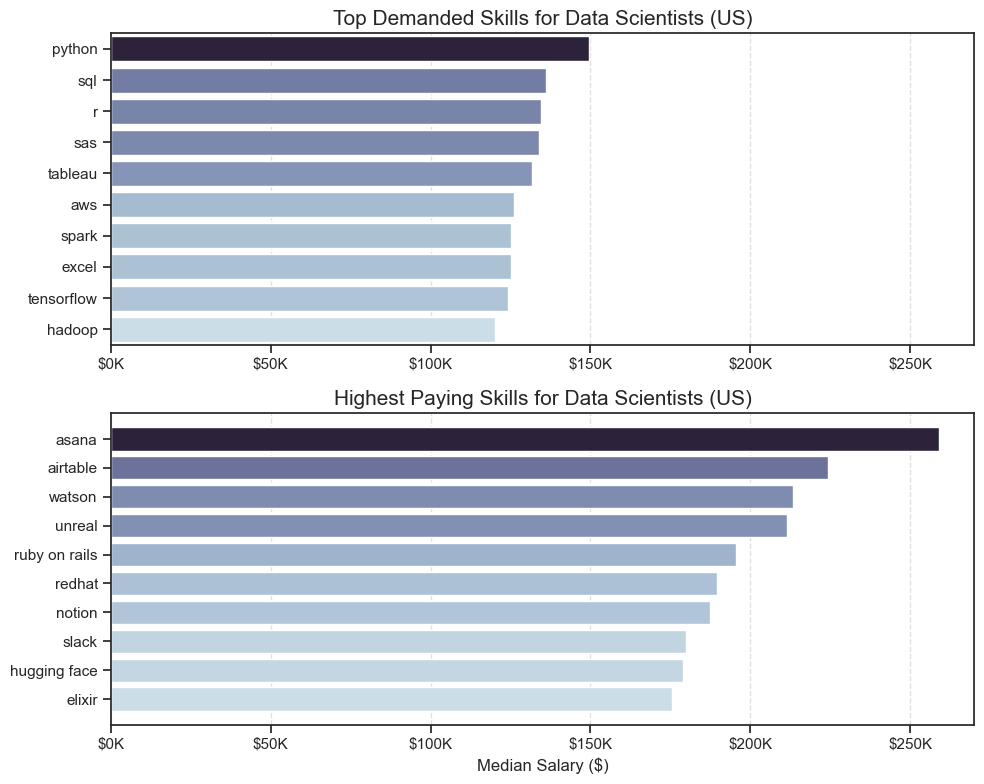

In [22]:
# now lets plot subplots for the graph
import matplotlib.ticker as mticker
from numpy import size
sns.set_theme(style='ticks')

fig, ax = plt.subplots(2,1,figsize=(10,8))

# subplot 1 (Using Seaborn)
# df_US_skill.sort_values(by='median',ascending=True).plot(kind='barh', y='median',ax=ax[0], legend=False)

sns.barplot(data=df_US_skill.sort_values(by='median',ascending=False), x='median', y=df_US_skill.index, hue='median',ax=ax[0],palette='ch:s=.25,rot=-.25')
ax[0].legend().remove()

# formatting
ax[0].set_title('Top Demanded Skills for Data Scientists (US)',fontsize=15)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].set_xlim(0,270000)
ax[0].grid(axis='x', linestyle='--', alpha=0.6)
ax[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1000:.0f}K'))

# subplot 2 (Using Seaborn)
# df_US_pay.sort_values(by='median',ascending=True).plot(kind='barh', y='median',ax=ax[1], legend=False)

sns.barplot(data=df_US_pay.sort_values(by='median',ascending=False), x='median', y=df_US_pay.index, hue='median',ax=ax[1],palette='ch:s=.25,rot=-.25')
ax[1].legend().remove()

# formatting
ax[1].set_title('Highest Paying Skills for Data Scientists (US)',fontsize=15)
ax[1].set_xlabel('Median Salary ($)')
ax[1].set_ylabel('')
ax[1].set_xlim(0,270000)
ax[1].grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

plt.tight_layout()
plt.plot()
